In [252]:
import numpy
import pandas

from matplotlib import pyplot
import seaborn

In [253]:
# Edades (años)
x1 = numpy.array([
    18,
    19,
    20,
    21,
    22,
    23,
    25,
    26,
    30,
    31,
    40,
    41,
    50,
    51,
])

# Pesos (kilogramos)
x2 = numpy.array([
    45,
    52,
    48,
    55,
    52,
    60,
    57,
    63,
    60,
    70,
    62,
    68,
    58,
    64,
])

# Distancias (kilómetros)
y = numpy.array([
    5.10,
    4.80,
    4.90,
    4.20,
    4.10,
    3.50,
    3.80,
    3.20,
    3.10,
    2.50,
    2.50,
    1.80,
    2.10,
    1.90,
])

In [254]:
X = numpy.array([x1, x2]).T

X

array([[18, 45],
       [19, 52],
       [20, 48],
       [21, 55],
       [22, 52],
       [23, 60],
       [25, 57],
       [26, 63],
       [30, 60],
       [31, 70],
       [40, 62],
       [41, 68],
       [50, 58],
       [51, 64]])

## Instalación de Tensorflow Keras

```bash
$ pip install tensorflow

$ pip install --upgrade keras
```

In [255]:
import keras

print(keras.__version__)

3.9.0


In [256]:
# Topología Full-Connected (De conexiones completas)

# El número de características de la entrada (hasta 10 veces el número de características)
# El número de observaciones que permitirán llenar el espacio (no tener más neuronas que observaciones)

# Arquitecturas por múltiplos de 2 (2, 4, 8, 16, 32, 64, 128, 256, ...)

# Funciones de activación:
# linear - Lineal y(-inf, inf)
# sigmoid - Logística y(0, 1)
# relu - ReLU y(0, inf)
# tanh - Tangente Hiperbólica y(-1, 1)

# En una capa oculta se busca no-linealidad, por lo que es común usar sigmoid/tanh/relu pero no lineal

modelo = keras.Sequential([
    # Input (Entradas)
    keras.Input(shape=(2,)), # shape - Una tupla con el número de características
    # Hidden (Intermedias / Ocultas / Capas Profundas)
    keras.layers.Dense(8, activation="sigmoid"), # número de neuronas y la función de activación
    # Output (Salidas) ! 1 neurona por salida / respuestas
    keras.layers.Dense(1, activation="linear") # número de salidas y la función de activación de la respuesta
    # La(s) neurona(s) que adaptan la respuesta
])

modelo.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_50 (Dense)                │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

In [257]:
# Optimizadores:
# sgd - Stochastic Gradient Descend (Calcula el tamaño de paso de forma estocástica)
# adam - Adaptive Moment Estimation (Dificulta más cambiar el gradiente)
# otros - rmsprop / lamb

# Funciones de pérdida:
# SALIDA LINEAL/RELU (linear/relu) - mse (MSE - Mean Square Error) / mae (Mean Absolute Error)
# SALIDA BINARIA (sigmoid) - binary_crossentropy (Entropía cruzada binaria)
# SALIDA MULTIBINARIA (CATEGÓRICA ONE-HOT) (softmax / sigmoid) - categorical_crossentropy (Entropía cruzada multibinaria)

# Métricas:
# LINEALES - mse / rmse / mae
# BINARIA - accuaracy

modelo.compile(
    optimizer="sgd",
    loss="mse",
    metrics=["mae"]
)

In [258]:
X, y

(array([[18, 45],
        [19, 52],
        [20, 48],
        [21, 55],
        [22, 52],
        [23, 60],
        [25, 57],
        [26, 63],
        [30, 60],
        [31, 70],
        [40, 62],
        [41, 68],
        [50, 58],
        [51, 64]]),
 array([5.1, 4.8, 4.9, 4.2, 4.1, 3.5, 3.8, 3.2, 3.1, 2.5, 2.5, 1.8, 2.1,
        1.9]))

In [259]:
historial = modelo.fit(X, y, epochs=100)

historial

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 15.7726 - mae: 3.8172
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 12.6310 - mae: 3.3866
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 10.1511 - mae: 3.0036
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 8.1871 - mae: 2.6608
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 6.6324 - mae: 2.3534
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 5.4074 - mae: 2.0791
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 4.4479 - mae: 1.8362
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 3.6979 - mae: 1.6237
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 3.1113 - mae: 1.4621
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.6522 - mae: 1.3194
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.2926 - mae: 1.1992
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.0109 - mae: 1.1037
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms

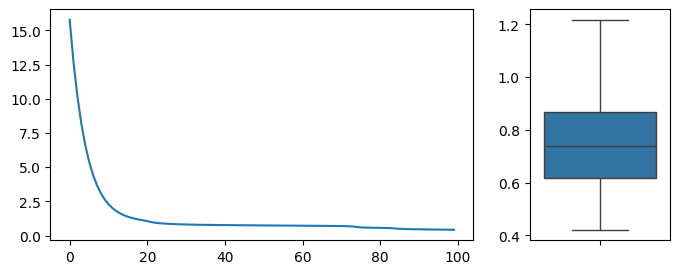

In [260]:
for metrica, valores in historial.history.items():
    if metrica == "loss":
        figure, axes = pyplot.subplots(1, 2, figsize=(8, 3), width_ratios=[3, 1])
        seaborn.lineplot(x=range(len(valores)), y=valores, ax=axes[0])
        seaborn.boxplot(y=valores, ax=axes[1], showfliers=False)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


<Axes: >

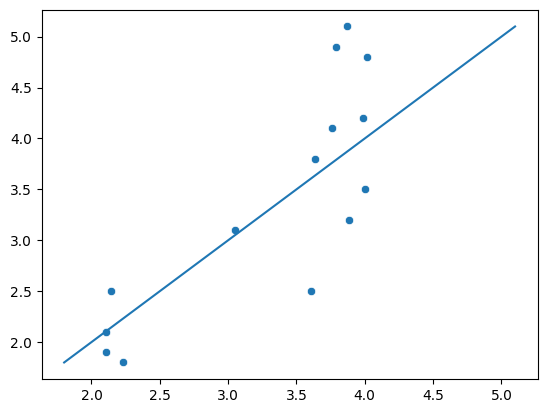

In [261]:
# y - respuesta original
# yp - predicción sobre cada observación original

yp = modelo.predict(X)[:, 0] # [:, 0] -> Todas las filas, primera columna

seaborn.scatterplot(x=yp, y=y)
seaborn.lineplot(x=y, y=y)

In [263]:
modelo.save("nn1_8x1.keras")

In [267]:
modelo = keras.models.load_model("nn1_8x1.keras")

modelo.predict(numpy.array([
    [18, 60],
    [19, 60],
    [20, 60],
    [21, 60],
]))[:, 0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([4.0549083, 4.053353 , 4.050103 , 4.0433226], dtype=float32)